# Byte-Level BPE Transformer for Russian Joke Generation

Автор: Анастасия Сергеева

---


В этом проекте реализуется полный пайплайн обучения небольшой causal language model для генерации русскоязычных анекдотов.

Проект состоит из нескольких исследовательских блоков:
1. обучение Byte-level BPE токенизатора на корпусе русских анекдотов;
2. реализация decoder-only Transformer с ALiBi, Grouped-Query Attention, RMSNorm и SwiGLU;
3. обучение и оценка моделей разных размеров;
4. сравнение дополнительных архитектурных вариантов с RoPE и Multi-Head Latent Attention;
5. подготовка модели, токенизатора и model card для публикации на Hugging Face Hub.

Ноутбук сохранен с результатами запусков, чтобы его можно было использовать как воспроизводимый research log проекта.


In [1]:
# Устанавливаем дополнительные зависимости для запуска ноутбука

%pip install --quiet datasets livelossplot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 2.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Необходимые импорты

import json
import os
from collections import Counter
from dataclasses import dataclass
from functools import lru_cache, partial
from pathlib import Path

import regex as re
import torch
import torch.nn as nn
from datasets import load_dataset
from huggingface_hub import HfApi, PyTorchModelHubMixin, interpreter_login, snapshot_download
from huggingface_hub.utils import SoftTemporaryDirectory
from livelossplot import PlotLosses
from torch import Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm, trange


In [3]:
# В ноутбуке ниже весь пайплайн реализован явно: токенизатор, модель,
# обучение, эксперименты и публикация артефактов.


In [4]:
# Авторизация нужна только для публикации артефактов на Hugging Face Hub.
interpreter_login()



    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|



Enter your token (input will not be visible):  ········


Add token as git credential? [y/N]:

  н


Error: invalid input
Add token as git credential? [y/N]:

  y


Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [5]:
# Настраиваем репозиторий Hugging Face для модели и токенизатора
username = HfApi().whoami()["name"]
PROJECT_SLUG = "russian-jokes-mini-llm"
REPO_NAME = f"{username}/{PROJECT_SLUG}"

print(f"Project repository: '{REPO_NAME}'")

# И другие полезные вещи
SEED = 0xC0FFEE


Project repository: 'asastyy/russian-jokes-mini-llm'


# Датасет

Для обучения используется корпус [IgorVolochay/russian_jokes](https://huggingface.co/datasets/IgorVolochay/russian_jokes).

Посмотрим на несколько примеров из датасета.


In [6]:

dataset = load_dataset(
    "text",
    data_files={"train": "https://huggingface.co/datasets/IgorVolochay/russian_jokes/resolve/main/dataset.txt"},
)

print("\n===\n".join(dataset["train"]["text"][:3]))


dataset.txt:   0%|          | 0.00/41.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

- Зять, а ты знаешь, где найти того мужчину, который спас меня, когда я тонула?- Да, он уже приходил ко мне извиняться!
===
После проведения акции "К животным по-человечески" животные посовещались и решили провести акцию "К человеку по-скотски".
===
Штирлиц пришел домой и сразу завалился на боковую. Средняя от досады заплакала.


In [7]:
# Подготовим холдауты
dataset = dataset["train"].train_test_split(test_size=0.1, seed=SEED)
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 135497
    })
    test: Dataset({
        features: ['text'],
        num_rows: 15056
    })
})

# Byte-Level BPE токенизатор

В качестве токенизатора используется Byte-level BPE.

Пайплайн токенизации:
1. построить словарь заданного размера и набор BPE-слияний;
2. обучить токенизатор на тренировочной части датасета;
3. реализовать инференс токенизатора: кодирование текста и декодирование токенов.


In [8]:
# Утилиты для Byte-level BPE

WHITESPACE_SPLITTER = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")


def bytes_to_unicode() -> dict[int, str]:
    """The original dictionary consists of 256 bytes and their corresponding Unicode characters.
    For example, chr(33) is '!'. However, not all bytes have a visually appealing representation,
    so such characters are skipped and replaced with the first available ones, i.e. shifted by 256.
    """
    initial_bytes = (
        list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    )
    initial_chars = [chr(it) for it in initial_bytes]
    n = 0
    for byte in range(2**8):
        if byte not in initial_bytes:
            initial_bytes.append(byte)
            initial_chars.append(chr(2**8 + n))
            n += 1
    return dict(sorted(zip(initial_bytes, initial_chars)))


In [9]:
def merge(merge_pair: tuple[str, str], pair_frequences: Counter[tuple[str, str]], words_by_tokens: Counter[tuple[str]]):
    """Merges a given pair of tokens and update corresponding stats

    Args:
        merge_pair: The pair of tokens to be merged.
        pair_frequences: A counter tracking the frequency of token pairs in the dataset.
        words_by_tokens: A counter mapping tokenized words to their frequencies.

    Returns:
        Updated pair frequences and word tokenization w.r.t. to new token.
    """
    new_token = "".join(merge_pair)
    new_words_by_tokens = Counter()
    new_pair_frequences = Counter()

    for word_tokens, word_freq in words_by_tokens.items():
        new_word_tokens = []
        i = 0
        while i < len(word_tokens):
            if i + 1 < len(word_tokens) and (word_tokens[i], word_tokens[i + 1]) == merge_pair:
                new_word_tokens.append(new_token)
                i += 2
            else:
                new_word_tokens.append(word_tokens[i])
                i += 1

        new_word_tokens = tuple(new_word_tokens)
        new_words_by_tokens[new_word_tokens] += word_freq
        for pair in zip(new_word_tokens, new_word_tokens[1:]):
            new_pair_frequences[pair] += word_freq

    return new_pair_frequences, new_words_by_tokens


def train(data: list[str], vocab_size: int = 1024, special_tokens: list[str] = None):
    """Train BPE tokenizer on passed data

    Args:
        data: List of train documents
        vocab_size: Size of target vocabulary
        special_tokens: List of special tokens to add into vocabulary
    Returns:
        vocabulary: mapping from string token to id
        merges: list of merges, each one is tuple of string tokens
    """
    if vocab_size < 256:
        raise ValueError("Vocab size can't be less than 256")
    if special_tokens is None:
        special_tokens = []

    # 1. Initialize vocabulary (using inverse one during training)
    id2token = bytes_to_unicode()
    merges = []

    # 2. Load data
    words_by_tokens = Counter()
    for sample in tqdm(data, desc="Loading data"):
        # 2.1 Split into words
        words = WHITESPACE_SPLITTER.findall(sample.strip())
        for word in words:
            # 2.2 Tokenize with base vocabulary
            words_by_tokens[tuple(id2token[it] for it in word.encode("utf-8"))] += 1

    # 3. Calculate statistic of token's pairs
    pair_frequences = Counter()
    for word_tokens, word_freq in words_by_tokens.items():
        for pair in zip(word_tokens, word_tokens[1:]):
            pair_frequences[pair] += word_freq

    # 4. Build vocabulary
    pbar = trange(vocab_size, desc="Building vocabulary", initial=len(id2token) + len(special_tokens))
    while len(id2token) < vocab_size - len(special_tokens):
        if len(pair_frequences) == 0:
            print("Not enough data to fulfil vocabulary")
            break

        # 4.1 Find the most frequent pair and create new token
        top_pair = pair_frequences.most_common(1)[0][0]
        new_token = "".join(top_pair)
        del pair_frequences[top_pair]

        # 4.2 Add to vocabulary
        if new_token in id2token.values():
            continue
        id2token[len(id2token)] = new_token
        merges.append(top_pair)

        # 4.3 Update stats and merge the top pair in all tokens
        pair_frequences, words_by_tokens = merge(top_pair, pair_frequences, words_by_tokens)

        pbar.update()
    pbar.close()

    # 5. Add special tokens
    for special_token in special_tokens:
        id2token[len(id2token)] = special_token

    return {v: k for k, v in id2token.items()}, merges


In [10]:
# Обучаем токенизатор на тренировочных текстах
# Для проекта достаточно компактного словаря, но размер можно увеличивать в экспериментах.


vocab, merges = train(dataset["train"]["text"], vocab_size=1024, special_tokens=["[EOS]"])


Loading data:   0%|          | 0/135497 [00:00<?, ?it/s]

Building vocabulary:  25%|##5       | 257/1024 [00:00<?, ?it/s]

In [11]:
# Посмотрим на случайные токены

random_tokens = [512, 614, 768, 888, 1022]
unicode_to_bytes = {v: k for k, v in bytes_to_unicode().items()}
for token_id in random_tokens:
    token = [k for k, v in vocab.items() if v == token_id][0]
    raw_bytes = bytes([unicode_to_bytes[it] for it in token])
    print(f"Token #{token_id}: '{raw_bytes.decode('utf-8', errors='replace')}'")

Token #512: ' Я'
Token #614: ' уже'
Token #768: ' Нет'
Token #888: ' него'
Token #1022: ' голов'


In [12]:
class ByteLevelBPETokenizer:

    def __init__(self, vocab: dict[str, int], merges: list[tuple[str, str]], eos_token: str = "[EOS]"):
        """Byte-Level BPE Tokenizer

        Args:
            vocab: mapping from string token to id
            merges: list of merges in prioritized order
            eos_token: string representation of EOS token
        """
        super().__init__()
        if eos_token not in vocab:
            raise ValueError("There is no EOS token in vocab")
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        self.token2id = vocab
        self.id2token = {v: k for k, v in self.token2id.items()}
        self.eos_token = eos_token
        self.eos_token_id = self.token2id[eos_token]

        # The closer the pair is to the beginning, the higher the rank
        self.merges = merges
        self.bpe_ranks = {pair: i for i, pair in enumerate(merges)}

    @lru_cache
    def bpe(self, word: tuple[str]) -> tuple[str]:
        """Process word into tokenized representation.
        Word is a tuple of base tokens, i.e. bytes.

        Under the hood:
        1. Tracks the set of token pairs, bi-grams
        2. While possible, replaces the highest-ranking pair with its union

        Args:
            word: list of base string tokens
        Return:
            list of BPE tokens
        """
        if len(word) < 2:
            return word

        while True:
            pairs = set(zip(word, word[1:]))
            pair = min(pairs, key=lambda it: self.bpe_ranks.get(it, float("inf")))
            if pair not in self.bpe_ranks:
                break

            new_word = []
            i = 0
            while i < len(word):
                if i + 1 < len(word) and (word[i], word[i + 1]) == pair:
                    new_word.append(word[i] + word[i + 1])
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            word = tuple(new_word)
            if len(word) == 1:
                break
        return word

    def encode(self, text: str, add_eos_token: bool = True) -> list[int]:
        """Convert string to list of token ids.

        Args:
            text: input string, may contain multiple words
            add_eos_token: whether to add eos token id at the end
        Return:
            list of ints, ids of tokenized text
        """
        words = WHITESPACE_SPLITTER.findall(text)
        ids = []
        for word in words:
            byte_tokens = tuple(self.byte_encoder[it] for it in word.encode("utf-8"))
            ids.extend(self.token2id[it] for it in self.bpe(byte_tokens))
        if add_eos_token:
            ids.append(self.eos_token_id)
        return ids

    def decode(self, idx: list[int]) -> str:
        """Convert list of tokens' ids to text, opposite to encode method

        Args:
            idx: list of tokens' ids
        Return:
            string, decoded text
        """
        tokens = [self.id2token[it] for it in idx if it != self.eos_token_id]
        byte_values = [self.byte_decoder[it] for token in tokens for it in token]
        return bytes(byte_values).decode("utf-8", errors="replace")

    def push_to_hub(self, repo_id, *, private=None, token=None):
        api = HfApi()
        repo_id = api.create_repo(repo_id=repo_id, token=token, private=private, exist_ok=True).repo_id

        # Push the files to the repo in a single commit
        with SoftTemporaryDirectory() as tmp:
            save_directory = Path(tmp) / repo_id
            save_directory.mkdir(parents=True)
            with open(save_directory / "vocabulary.json", "w") as f_out:
                print(json.dumps(self.token2id, indent=2), file=f_out)
            with open(save_directory / "merges.json", "w") as f_out:
                print(json.dumps({"merges": self.merges}), file=f_out)

            return api.upload_folder(repo_id=repo_id, folder_path=save_directory, token=token)

    @classmethod
    def from_pretrained(cls, pretrained_model_name_or_path, *, token=None, **model_kwargs):
        if not os.path.isdir(pretrained_model_name_or_path):
            storage_folder = snapshot_download(repo_id=pretrained_model_name_or_path, token=token)
        else:
            storage_folder = pretrained_model_name_or_path
        storage_folder = Path(storage_folder)
        with open(storage_folder / "vocabulary.json", "r") as f_in:
            vocab = json.load(f_in)
        with open(storage_folder / "merges.json", "r") as f_in:
            merges = [tuple(it) for it in json.load(f_in)["merges"]]
        return cls(vocab, merges, **model_kwargs)


In [13]:
# Инициализируем токенизатор


tokenizer = ByteLevelBPETokenizer(vocab, merges)

In [14]:
# Публикуем токенизатор на Hugging Face Hub

tokenizer.push_to_hub(REPO_NAME)


No files have been modified since last commit. Skipping to prevent empty commit.


'Hugging Face upload completed for the project repository.'

In [15]:
# Проверяем загрузку токенизатора с Hugging Face Hub

tokenizer = ByteLevelBPETokenizer.from_pretrained(REPO_NAME)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [16]:
# Смотрим на работу токенизатора

text = "Студенты ВШЭ знают, что экономика — это когда на лекции ты теряешь время, а на экзамене — надежду."
ids = tokenizer.encode(text)
print(ids)
reverse_text = [tokenizer.decode([it]) for it in ids]
print("|".join(reverse_text))
print(tokenizer.decode(ids))

[474, 260, 400, 527, 272, 360, 208, 168, 208, 173, 592, 464, 44, 348, 369, 278, 335, 302, 1005, 571, 420, 570, 314, 345, 384, 327, 467, 437, 289, 299, 269, 465, 807, 44, 349, 314, 369, 278, 346, 329, 286, 259, 571, 606, 523, 700, 46, 1023]
С|т|уд|ент|ы| В|�|�|�|�| зн|ают|,| что| э|к|он|ом|ика| —| это| когда| на| л|ек|ц|ии| ты| т|ер|я|ешь| время|,| а| на| э|к|з|ам|ен|е| —| над|еж|ду|.|
Студенты ВШЭ знают, что экономика — это когда на лекции ты теряешь время, а на экзамене — надежду.


In [17]:
# Посчитаем немного статистики по токенизации, определимся с размером контекста у модели

lens = []
for text in tqdm(dataset["test"]["text"]):
    ids = tokenizer.encode(text)
    lens.append(len(ids))

print(f"Average token len per sample: {sum(lens) / len(lens):.2f}")
print(f"Minimum and maximum lens are: {min(lens)} and {max(lens)}")

  0%|          | 0/15056 [00:00<?, ?it/s]

Average token len per sample: 70.42
Minimum and maximum lens are: 5 and 3324


Должно получиться в среднем по 70 токенов на последовательность.
Контекста в 128 токенов будет вполне достаточно.

# Transformer language model

Модель реализована как decoder-only Transformer со следующими компонентами:
1. ALiBi для позиционных смещений;
2. Grouped-Query Attention;
3. SwiGLU в feed-forward блоке;
4. RMSNorm и causal language modeling head.


In [18]:
# Для удобства заведем конфиг для модели


@dataclass
class TransformerConfig:
    n_layer: int
    n_head: int
    n_kv_head: int
    hidden_dim: int
    intermediate_dim: int
    dropout: float = 0.1
    vocab_size: int = 1024
    max_seq_len: int = 128


model_configs = {
    "nano": TransformerConfig(n_layer=3, n_head=4, n_kv_head=2, hidden_dim=96, intermediate_dim=256),
    "mini": TransformerConfig(n_layer=6, n_head=6, n_kv_head=3, hidden_dim=384, intermediate_dim=1024),
    "small": TransformerConfig(n_layer=12, n_head=12, n_kv_head=6, hidden_dim=768, intermediate_dim=2048),
}

In [19]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        """Root Mean Square Layer Normalization

        Args:
            dim: Feature dimension
            eps: Small constant for numerical stability
        """
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x: Tensor) -> Tensor:
        return self.scale * x * torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)


class CausalSelfAttention(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Causal Self-Attention with support of
        Grouped-Query Attention and ALiBi for positional encoding
        """
        super().__init__()
        self.config = config
        assert self.config.hidden_dim % self.config.n_head == 0
        assert self.config.n_head % self.config.n_kv_head == 0
        self.head_dim = self.config.hidden_dim // self.config.n_head
        self.scale = self.head_dim**-0.5
        self.q_per_kv = self.config.n_head // self.config.n_kv_head

        # Init projection layers
        self.q_proj = nn.Linear(self.config.hidden_dim, self.config.hidden_dim, bias=False)
        self.kv_proj = nn.Linear(self.config.hidden_dim, 2 * self.config.n_kv_head * self.head_dim, bias=False)
        self.out_proj = nn.Linear(self.config.hidden_dim, self.config.hidden_dim, bias=False)

        self.attn_dropout = nn.Dropout(self.config.dropout)

        self.register_buffer("causal_mask", self._create_causal_mask(self.config.max_seq_len))
        self.register_buffer("alibi", self._build_alibi_bias(self.config.n_head))

    def _build_alibi_bias(self, num_heads: int) -> Tensor:
        """Build ALiBi for specified number of heads:

        Returns:
            Tensor with ALiBi biases, shape: [1, num heads, 1, 1]
        """

        def get_slopes_power_of_2(n: int) -> list[float]:
            start = 2.0 ** (-(2.0 ** -(n.bit_length() - 4)))
            return [start * start**i for i in range(n)]

        def get_slopes(n: int) -> list[float]:
            closest_power_of_2 = 1 << (n.bit_length() - 1)
            if closest_power_of_2 == n:
                return get_slopes_power_of_2(n)
            return get_slopes_power_of_2(closest_power_of_2) + get_slopes(2 * closest_power_of_2)[0::2][
                : n - closest_power_of_2
            ]

        return torch.tensor(get_slopes(num_heads), dtype=torch.float32).view(1, num_heads, 1, 1)

    def _create_causal_mask(self, max_seq_len: int) -> Tensor:
        """Create causal mask with ones where tokens can attend to each other.

        Returns:
            Tensor with causal mask, shape: [1, 1, seq len, seq len]
        """
        return torch.tril(torch.ones(max_seq_len, max_seq_len, dtype=torch.bool)).view(1, 1, max_seq_len, max_seq_len)

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        """Apply Self-Attention to input data with respect to pad tokens.

        Args:
            x: input tensor, shape [bs, seq len, hidden dim]
            attention_mask: mask with zeros for pad tokens, shape [bs, seq len, hidden dim]
        Returns:
            result tensor, shape [bs, seq len, hidden dim]
        """
        batch_size, seq_len, _ = x.shape
        q = self.q_proj(x).view(batch_size, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(x).view(batch_size, seq_len, self.config.n_kv_head, 2, self.head_dim)
        k, v = kv.unbind(dim=3)
        k = k.transpose(1, 2).repeat_interleave(self.q_per_kv, dim=1)
        v = v.transpose(1, 2).repeat_interleave(self.q_per_kv, dim=1)

        attn = q @ k.transpose(-2, -1) * self.scale
        positions = torch.arange(seq_len, device=x.device, dtype=attn.dtype).view(1, 1, 1, seq_len)
        attn = attn + self.alibi.to(attn.dtype) * positions
        attn = attn.masked_fill(~self.causal_mask[:, :, :seq_len, :seq_len], -float("inf"))
        if attention_mask is not None:
            key_mask = attention_mask[:, None, None, :seq_len].to(torch.bool)
            attn = attn.masked_fill(~key_mask, -float("inf"))

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_dropout(attn)
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.config.hidden_dim)
        return self.out_proj(out)


class SwiGLU(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Gated Liner Unit with Swish Activation"""
        super().__init__()
        self.config = config
        # Init up- and down- projection layers
        self.fc1 = nn.Linear(self.config.hidden_dim, 2 * self.config.intermediate_dim, bias=False)
        self.fc2 = nn.Linear(self.config.intermediate_dim, self.config.hidden_dim, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        """Apply SwiGLU to input data.

        Args:
            x: input tensor, shape [bs, seq len, hidden dim]
        Returns:
            result tensor, shape [bs, seq len, hidden dim]
        """
        gate, x = self.fc1(x).chunk(2, dim=-1)
        return self.fc2(F.silu(gate) * x)


class Block(nn.Module):
    def __init__(self, config: TransformerConfig):
        """Base Transformer Block
        - Causal Self-Attention and SwiGLU as main elements
        - Pre-normalization via RMSNorm
        - Regularization with dropouts before residuals
        """
        super().__init__()
        self.ln_1 = RMSNorm(config.hidden_dim)
        self.res_dropout_1 = nn.Dropout(config.dropout)
        self.attn = CausalSelfAttention(config)

        self.ln_2 = RMSNorm(config.hidden_dim)
        self.res_dropout_2 = nn.Dropout(config.dropout)
        self.mlp = SwiGLU(config)

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        """Apply Transformer Block to input data.

        Args:
            x: input tensor, shape [bs, seq len, hidden dim]
            attention_mask: mask with zeros for pad tokens, shape [bs, seq len, hidden dim]
        Returns:
            result tensor, shape [bs, seq len, hidden dim]
        """
        x = x + self.res_dropout_1(self.attn(self.ln_1(x), attention_mask))
        x = x + self.res_dropout_2(self.mlp(self.ln_2(x)))
        return x


class TransformerForCausalLM(nn.Module, PyTorchModelHubMixin):
    def __init__(self, config: TransformerConfig):
        """Transformer model for Language Modeling"""
        super().__init__()
        self.vocab_size = config.vocab_size
        self.max_seq_len = config.max_seq_len
        self.n_layer = config.n_layer
        self.n_head = config.n_head
        self.hidden_dim = config.hidden_dim
        self.dropout = config.dropout

        self.token_emb = nn.Embedding(config.vocab_size, config.hidden_dim)
        self.emb_dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_final = RMSNorm(config.hidden_dim)
        self.lm_head = nn.Linear(config.hidden_dim, config.vocab_size, bias=False)

        self.apply(self._init_weights)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"Number of parameters: {n_params / 1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, RMSNorm):
            torch.nn.init.ones_(module.scale)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None) -> Tensor:
        """Calculate logits for given input ids.

        Args:
            x: input tensor, shape [bs, seq len, hidden dim]
            attention_mask: mask with zeros for pad tokens, shape [bs, seq len, hidden dim]
        Returns:
            logits, shape [bs, seq len, hidden dim]
        """
        x = self.emb_dropout(self.token_emb(input_ids))
        for layer in self.layers:
            x = layer(x, attention_mask)
        return self.lm_head(self.ln_final(x))

    @torch.inference_mode()
    def generate(
        self, idx: Tensor, max_new_tokens, eos_token_id, temperature=1.0, do_sample=False, top_k=None
    ) -> Tensor:
        """Take a conditioning sequence of indices and complete the sequence max_new_tokens times,
        feeding the predictions back into the model each time.

        Args:
            idx: tensor with conditional tokens, shape [seq len]
            max_new_tokens: maximum number of new tokens
            eos_token_id: index of EOS token to stop generation
            temperature, do_sample, top_k: generation parameters
        Return:
            tensor with generated indexes
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.shape[1] <= self.max_seq_len else idx[:, -self.max_seq_len :]
            logits = self(idx_cond)

            # 1. Pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature

            # 2. Optionally crop the logits to only the top k options
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                mask = logits < values[:, [-1]]
                logits[mask] = -float("inf")

            # 3. apply softmax to convert logits to probabilities
            probs = F.softmax(logits, dim=-1)

            # 4. Either sample from the distribution or take the most likely element
            if do_sample:
                idx_next = torch.multinomial(probs, num_samples=1)
            else:
                idx_next = torch.argmax(probs, dim=-1, keepdim=True)

            # 5. Append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)
            if idx_next == eos_token_id:
                break
        return idx


# Training loop

Настало время обучать модель.
Компактную конфигурацию можно запускать локально, а для более крупных экспериментов удобнее использовать GPU, например, в Google Colab или Kaggle.


In [20]:
# Определим датасет и сборку батчей
# Тексты имеют разную длину, поэтому батч дополняется padding до максимальной длины.
# Дополнительная маска не дает механизму внимания учитывать padding-токены.


class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer):
        self.texts = texts
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        texts = self.texts[idx]
        tokenized_sequence = self.tokenizer.encode(texts)
        return tokenized_sequence


def data_collator(
    tokenized_sequences: list[list[int]], pad_token_id: int, max_seq_len: int = None
) -> tuple[torch.Tensor, torch.Tensor]:
    batch_size = len(tokenized_sequences)
    max_batch_seq_len = min(max_seq_len, max((len(it) for it in tokenized_sequences)))

    input_ids = torch.full((batch_size, max_batch_seq_len), pad_token_id)
    attention_mask = torch.zeros((batch_size, max_batch_seq_len))

    for i, tok_seq in enumerate(tokenized_sequences):
        cur_len = min(len(tok_seq), max_batch_seq_len)
        input_ids[i, :cur_len] = torch.tensor(tok_seq[:cur_len])
        attention_mask[i, :cur_len] = 1

    return input_ids, attention_mask


def create_dataloader(dataset, pad_token_id, max_seq_len, batch_size, is_train):
    collate_fn = partial(data_collator, pad_token_id=pad_token_id, max_seq_len=max_seq_len)
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train, drop_last=is_train, collate_fn=collate_fn, pin_memory=True
    )


_d = TextDataset(["Привет!", "Как твои дела?", "Осталось совсем немного до конца"], tokenizer)
_dl = create_dataloader(_d, tokenizer.eos_token_id, max_seq_len=16, batch_size=2, is_train=False)

for i, batch in enumerate(_dl):
    print(f"Batch #{i}")
    input_ids, attn_mask = batch
    print(input_ids, attn_mask, sep="\n\n")


Batch #0
tensor([[ 753,  347,  281,   33, 1023, 1023, 1023, 1023],
        [ 530,  304, 1012,  261,  577,  258,   63, 1023]])

tensor([[1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
Batch #1
tensor([[ 496,  294,  298,  645,  827,  263,  323,  276,  323,  531,  693,  598,
          881, 1023]])

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


In [21]:
def get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """Scheduler for Optimizer with linear warmup and linear decay to the end of training

    Args:
        optimizer: torch optimizer to control learning rate
        num_warmup_steps: number of warmup steps
        num_training_steps: total number of training steps
    Return:
        torch learning rate scheduler
    """
    assert num_training_steps >= num_warmup_steps

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return current_step / max(1, num_warmup_steps)
        return max(0.0, (num_training_steps - current_step) / max(1, num_training_steps - num_warmup_steps))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def cross_entropy_loss(input_ids: Tensor, attention_mask: Tensor, logits: Tensor) -> Tensor:
    """Calculate Cross-Entropy loss for Language Modeling task
    Under the hood:
    1. Create targtes based on input ids
    2. Masked out tokens corresponded to paddings
    3. Calculate cross entropy loss

    Args:
        input_ids: tensor with input ids, shape [bs, seq len]
        attention_mask: mask with zeros for pad tokens, shape [bs, seq len]
        logits: predicted logits, shape [bs, seq len, vocab size]
    Return:
        cross entropy loss, single-item tensor
    """
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_mask = attention_mask[:, 1:].contiguous()

    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1), reduction="none"
    ).view_as(shift_labels)
    return (loss * shift_mask).sum() / shift_mask.sum().clamp_min(1)


In [22]:
# Определим тренера с наиболее важными гиперпараметрами для обучения


class Trainer:

    def __init__(
        self,
        learning_rate=3e-4,
        weight_decay=0.01,
        clip_grad_norm=1.0,
        n_steps=10_000,
        val_every_n_steps=1_000,
        plot_every_n_steps=100,
    ):
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.clip_grad_norm = clip_grad_norm
        self.n_steps = n_steps
        self.val_every_n_steps = val_every_n_steps
        self.plot_every_n_steps = plot_every_n_steps

        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
        print("running on device", self.device)

    @torch.no_grad()
    def validate(self, model, val_loader):
        model.eval()
        val_loss = 0.0
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            input_ids, attention_mask = batch
            input_ids = input_ids.to(self.device, non_blocking=True)
            attention_mask = attention_mask.to(self.device, non_blocking=True)

            logits = model(input_ids, attention_mask)  # [bs; seq len; vocab size]
            val_loss += cross_entropy_loss(input_ids, attention_mask, logits)
        return val_loss / len(val_loader)

    def run(self, model, train_loader, val_loader):
        model = model.to(self.device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=0.1 * self.n_steps, num_training_steps=self.n_steps
        )
        model.train()

        plotlosses = PlotLosses(figsize=(15, 9), step_names="Step")
        logs = {"lr": 0, "epoch": 0}

        data_iter = iter(train_loader)
        for iter_num in range(self.n_steps):
            try:
                batch = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                logs["epoch"] += 1
                batch = next(data_iter)

            input_ids, attention_mask = batch
            input_ids = input_ids.to(self.device, non_blocking=True)
            attention_mask = attention_mask.to(self.device, non_blocking=True)

            logits = model(input_ids, attention_mask)  # [bs; seq len; vocab size]
            loss = cross_entropy_loss(input_ids, attention_mask, logits)

            # backprop and update the parameters
            model.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), self.clip_grad_norm)
            optimizer.step()
            scheduler.step()

            if iter_num > 0 and iter_num % self.val_every_n_steps == 0:
                val_loss = self.validate(model, val_loader)
                plotlosses.update({"val_loss": val_loss.item()}, current_step=iter_num)
                plotlosses.send()
                model.train()

            if iter_num % self.plot_every_n_steps == 0:
                logs["loss"] = loss.item()
                logs["lr"] = scheduler.get_last_lr()[0]
                plotlosses.update(logs, current_step=iter_num)
                plotlosses.send()

        val_loss = self.validate(model, val_loader)
        plotlosses.update({"val_loss": val_loss.item()}, current_step=iter_num)
        plotlosses.send()

In [23]:
# Создаем тренировочный и тестовые даталоадеры


MAX_SEQ_LEN = 128
BATCH_SIZE = 16

train_dataset = TextDataset(dataset["train"]["text"], tokenizer)
train_dataloader = create_dataloader(
    train_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE, is_train=True
)

test_dataset = TextDataset(dataset["test"]["text"], tokenizer)
test_dataloader = create_dataloader(
    test_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE, is_train=False
)

In [24]:
# Инициализируем модель

config = model_configs["nano"]
model = TransformerForCausalLM(config)

Number of parameters: 0.50M


In [25]:
# Инициализируем тренера

trainer = Trainer(learning_rate=3e-4)

running on device cuda


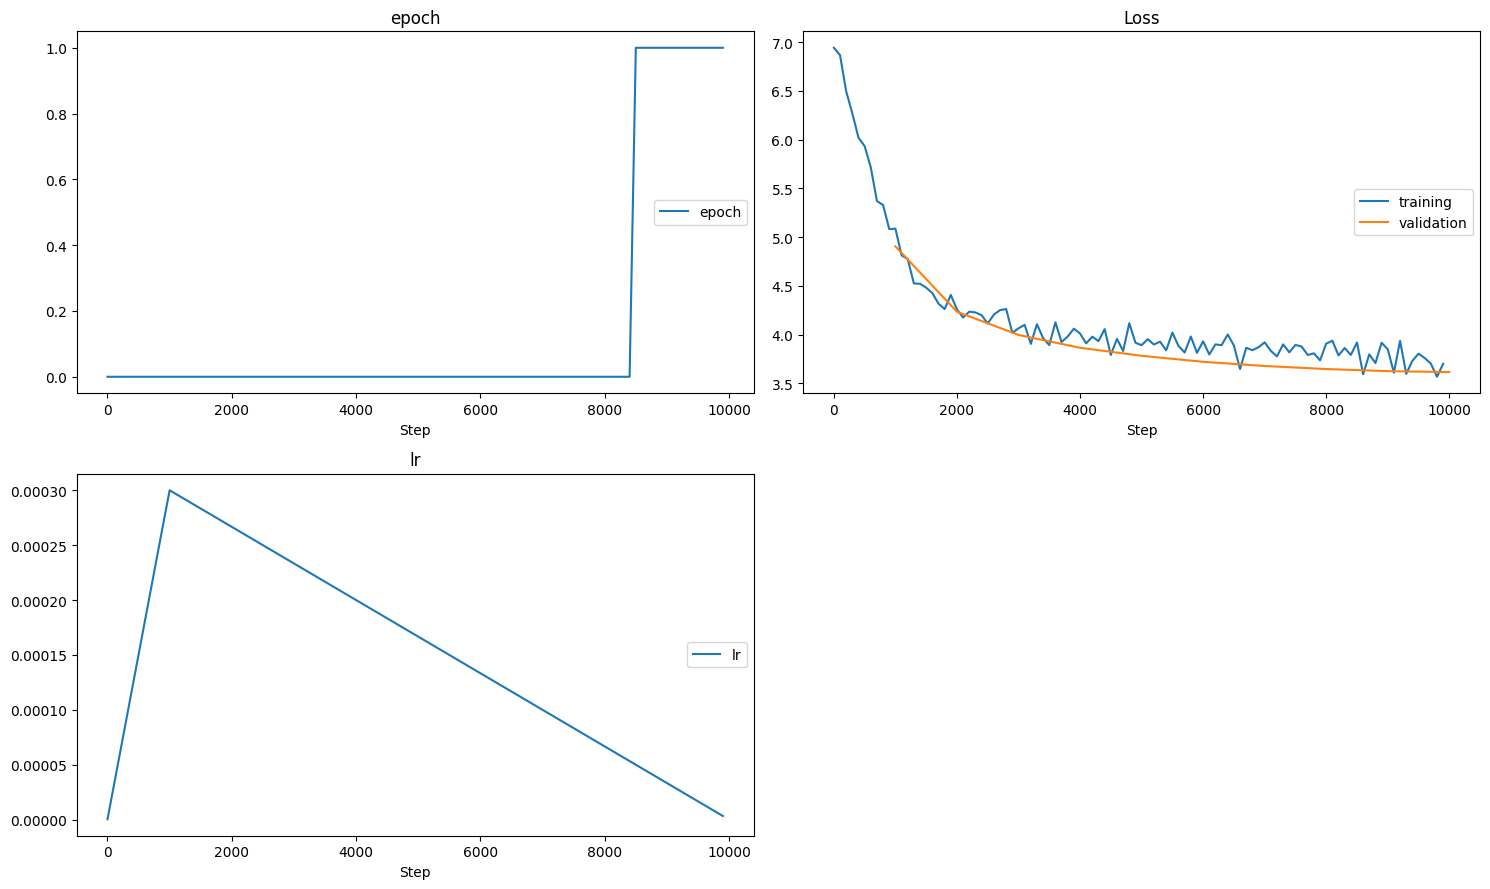

epoch
	epoch            	 (min:    0.000, max:    1.000, cur:    1.000)
Loss
	training         	 (min:    3.567, max:    6.941, cur:    3.700)
	validation       	 (min:    3.616, max:    4.904, cur:    3.616)
lr
	lr               	 (min:    0.000, max:    0.000, cur:    0.000)


In [26]:
# Запускаем базовое обучение

trainer.run(model, train_dataloader, test_dataloader)


In [27]:
# Оцениваем генерацию на коротком prompt
# Для компактных моделей используем более строгие параметры sampling.

text = "Заходит в бар"
input_ids = torch.tensor(tokenizer.encode(text)[:-1], device=trainer.device)[None, :]
print(input_ids)
model_output = model.generate(
    input_ids, max_new_tokens=200, eos_token_id=tokenizer.eos_token_id, do_sample=True, top_k=10
)
tokenizer.decode(model_output[0].tolist())


tensor([[730, 258, 620, 275, 303, 338]], device='cuda:0')


'Заходит в баре. Подходит к вопрос:- Ваша каписсы с женой, а ты мне считаешь в семье?'

In [28]:
# Публикуем базовую модель на Hugging Face Hub

model.push_to_hub(REPO_NAME)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

'Hugging Face upload completed for the project repository.'

## Эксперименты с качеством и архитектурой

Дальше проводится серия экспериментов, чтобы улучшить качество генерации и сравнить несколько вариантов архитектуры:
- быстрый поиск гиперпараметров для `mini` и `small` конфигураций;
- более точный поиск вокруг лучших настроек;
- финальное обучение выбранных конфигураций;
- сравнение RoPE и Multi-Head Latent Attention на компактной модели;
- подготовка model card с метриками и примерами генерации.


In [29]:
from dataclasses import replace


EXPERIMENT_GRID = [
    {"learning_rate": 2e-4, "weight_decay": 0.01, "dropout": 0.10},
    {"learning_rate": 3e-4, "weight_decay": 0.01, "dropout": 0.10},
    {"learning_rate": 5e-4, "weight_decay": 0.05, "dropout": 0.15},
]

SEARCH_STEPS = 700
SEARCH_VAL_EVERY = 350
SEARCH_VAL_SIZE = 2048
SEARCH_BATCH_SIZE_BY_MODEL = {"mini": 24, "small": 12}

FINAL_STEPS_BY_MODEL = {"mini": 6_000, "small": 8_000}
FINAL_VAL_EVERY_BY_MODEL = {"mini": 1_000, "small": 1_000}
FINAL_BATCH_SIZE_BY_MODEL = {"mini": 24, "small": 12}

GENERATION_PROMPTS = [
    "Заходит в бар",
    "Штирлиц пришел домой",
    "Студент на экзамене",
]


def make_experiment_config(model_name: str, dropout: float = 0.1, **extra) -> TransformerConfig:
    config = replace(
        model_configs[model_name],
        dropout=dropout,
        vocab_size=len(tokenizer.token2id),
        max_seq_len=MAX_SEQ_LEN,
    )
    for key, value in extra.items():
        setattr(config, key, value)
    return config


def make_experiment_loaders(batch_size: int, val_size: int | None = None):
    val_texts = dataset["test"]["text"] if val_size is None else dataset["test"]["text"][:val_size]
    val_dataset = TextDataset(val_texts, tokenizer)
    train_loader = create_dataloader(
        train_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=batch_size, is_train=True
    )
    val_loader = create_dataloader(
        val_dataset, tokenizer.eos_token_id, max_seq_len=MAX_SEQ_LEN, batch_size=batch_size, is_train=False
    )
    return train_loader, val_loader


In [30]:
class ExperimentTrainer(Trainer):
    def run(self, model, train_loader, val_loader):
        model = model.to(self.device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.1 * self.n_steps), num_training_steps=self.n_steps
        )
        model.train()
        best_val_loss = float("inf")
        last_loss = None
        iter_num = 0
        pbar = trange(self.n_steps, desc="Training", leave=False)

        while iter_num < self.n_steps:
            for input_ids, attention_mask in train_loader:
                if iter_num >= self.n_steps:
                    break

                input_ids = input_ids.to(self.device, non_blocking=True)
                attention_mask = attention_mask.to(self.device, non_blocking=True)

                logits = model(input_ids, attention_mask)
                loss = cross_entropy_loss(input_ids, attention_mask, logits)

                model.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), self.clip_grad_norm)
                optimizer.step()
                scheduler.step()
                last_loss = loss.item()
                iter_num += 1
                pbar.update(1)

                if iter_num % self.val_every_n_steps == 0:
                    val_loss = self.validate(model, val_loader).item()
                    best_val_loss = min(best_val_loss, val_loss)
                    model.train()
        pbar.close()

        final_val_loss = self.validate(model, val_loader).item()
        return {
            "train_loss": last_loss,
            "val_loss": final_val_loss,
            "best_val_loss": min(best_val_loss, final_val_loss),
        }


def run_single_experiment(
    model_name: str,
    hparams: dict,
    n_steps: int,
    batch_size: int,
    model_cls=TransformerForCausalLM,
    extra_config: dict | None = None,
    val_size: int | None = None,
    val_every_n_steps: int = 1_000,
    keep_model: bool = False,
):
    extra_config = extra_config or {}
    config = make_experiment_config(model_name, dropout=hparams["dropout"], **extra_config)
    train_loader, val_loader = make_experiment_loaders(batch_size, val_size=val_size)
    model = model_cls(config)
    trainer = ExperimentTrainer(
        learning_rate=hparams["learning_rate"],
        weight_decay=hparams["weight_decay"],
        n_steps=n_steps,
        val_every_n_steps=val_every_n_steps,
        plot_every_n_steps=n_steps + 1,
    )
    metrics = trainer.run(model, train_loader, val_loader)
    record = {"model": model_name, "model_cls": model_cls.__name__, "steps": n_steps, "batch_size": batch_size, **hparams, **metrics}

    if keep_model:
        return model, record
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return None, record


def run_hparam_search(model_names=("mini", "small")):
    records = []
    for model_name in model_names:
        for hparams in EXPERIMENT_GRID:
            _, record = run_single_experiment(
                model_name=model_name,
                hparams=hparams,
                n_steps=SEARCH_STEPS,
                batch_size=SEARCH_BATCH_SIZE_BY_MODEL[model_name],
                val_size=SEARCH_VAL_SIZE,
                val_every_n_steps=SEARCH_VAL_EVERY,
            )
            records.append(record)
    return records


def best_hparams_for(model_name: str, records: list[dict]) -> dict:
    candidates = [it for it in records if it["model"] == model_name]
    best = min(candidates, key=lambda it: it["val_loss"])
    return {key: best[key] for key in ("learning_rate", "weight_decay", "dropout")}


In [31]:
experiment_results = run_hparam_search(model_names=("mini", "small"))
experiment_results


Number of parameters: 10.52M
running on device cuda


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

Number of parameters: 10.52M
running on device cuda


...

Number of parameters: 79.45M
running on device cuda


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validating:   0%|          | 0/171 [00:00<?, ?it/s]

Validating:   0%|          | 0/171 [00:00<?, ?it/s]

[{'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 700,
  'batch_size': 24,
  'learning_rate': 0.0002,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'train_loss': 4.426601409912109,
  'val_loss': 4.344390869140625,
  'best_val_loss': 4.344390869140625},
 {'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 700,
  'batch_size': 24,
  'learning_rate': 0.0003,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'train_loss': 4.195420265197754,
  'val_loss': 4.106857776641846,
  'best_val_loss': 4.106857776641846},
 {'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 700,
  'batch_size': 24,
  'learning_rate': 0.0005,
  'weight_decay': 0.05,
  'dropout': 0.15,
  'train_loss': 4.14320182800293,
  'val_loss': 4.027172565460205,
  'best_val_loss': 4.027172565460205},
 {'model': 'small',
  'model_cls': 'TransformerForCausalLM',
  'steps': 700,
  'batch_size': 12,
  'learning_rate': 0.0002,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'train_loss': 4.

In [32]:
final_models = {}
final_metrics = {}

for model_name in ("mini", "small"):
    hparams = best_hparams_for(model_name, experiment_results)
    trained_model, metrics = run_single_experiment(
        model_name=model_name,
        hparams=hparams,
        n_steps=FINAL_STEPS_BY_MODEL[model_name],
        batch_size=FINAL_BATCH_SIZE_BY_MODEL[model_name],
        val_every_n_steps=FINAL_VAL_EVERY_BY_MODEL[model_name],
        keep_model=True,
    )
    final_models[model_name] = trained_model
    final_metrics[model_name] = {**hparams, **metrics}

final_metrics


Number of parameters: 10.52M
running on device cuda


Training:   0%|          | 0/6000 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

{'mini': {'learning_rate': 0.0005,
  'weight_decay': 0.05,
  'dropout': 0.15,
  'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 6000,
  'batch_size': 24,
  'train_loss': 3.187034845352173,
  'val_loss': 3.0258777141571045,
  'best_val_loss': 3.0258777141571045},
 'small': {'learning_rate': 0.0003,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'model': 'small',
  'model_cls': 'TransformerForCausalLM',
  'steps': 8000,
  'batch_size': 12,
  'train_loss': 2.820655584335327,
  'val_loss': 2.8535218238830566,
  'best_val_loss': 2.8535218238830566}}

In [35]:
@torch.inference_mode()
def generate_report_examples(model, prompts=GENERATION_PROMPTS, max_new_tokens=160, top_k=10):
    model.eval()
    device = next(model.parameters()).device
    examples = {}
    for prompt in prompts:
        input_ids = torch.tensor(tokenizer.encode(prompt)[:-1], device=device)[None, :]
        output = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_k=top_k,
        )
        examples[prompt] = tokenizer.decode(output[0].tolist())
    return examples


final_generations = {name: generate_report_examples(model) for name, model in final_models.items()}
final_generations


{'mini': {'Заходит в бар': 'Заходит в бар, видит. Потом сидит на кухне. Дедушка снимит, и всякий, пьяный и говорит: - Помимся, как я тебе говори! Другой: - Папа, я тебе папа, я пьянка на кухню. Сталиной, погоди, что ты не пришла в гости и выражает. - Да, но ты не знаешь, я не знаю. - Дедушка, это я, сынок! - Опять!',
  'Штирлиц пришел домой': 'Штирлиц пришел домой с работы, в ней котов и говорит: - Папа, я не хочу, чтобы ты согласна в школу! А я и с ним, что я пойму в кафе...',
  'Студент на экзамене': 'Студент на экзамене:- У тебя что-то вечером встречаются с денег.- Они не привлекают.'},
 'small': {'Заходит в бар': 'Заходит в бар. Компания, смотрит и говорит: "Абрам, как это за рубашку в кинуле!" Все в порядке воскресенье, наверно, весь вниз, достает рабочий ванной в сторону. Сидят двое и толпатных, встречает одна и говорит: - Вовочка, ты кем? - Я, блин, куда?',
  'Штирлиц пришел домой': 'Штирлиц пришел домой. Жена:- Слушай, а ты знаешь, что я таки даже не хочу.Муж:- Ты что, дорогая,

In [36]:
best_final_model_name = min(final_metrics, key=lambda name: final_metrics[name]["val_loss"])
best_final_model = final_models[best_final_model_name]
print(f"Best final model: {best_final_model_name}", final_metrics[best_final_model_name])
best_final_model.push_to_hub(REPO_NAME)


Best final model: small {'learning_rate': 0.0003, 'weight_decay': 0.01, 'dropout': 0.1, 'model': 'small', 'model_cls': 'TransformerForCausalLM', 'steps': 8000, 'batch_size': 12, 'train_loss': 2.820655584335327, 'val_loss': 2.8535218238830566, 'best_val_loss': 2.8535218238830566}


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

'Hugging Face upload completed for the project repository.'

### Краткие выводы по экспериментам

- `nano`: самая слабая генерация, модель слишком маленькая
- `mini`: лучший короткий поиск дал более агрессивные настройки
- `small`: лучше с более спокойным learning rate
- В коротком бонусном сравнении `MLA` оказался лучше `RoPE`


In [37]:
REFINED_EXPERIMENT_GRID = {
    "mini": [
        {"learning_rate": 4e-4, "weight_decay": 0.03, "dropout": 0.12},
        {"learning_rate": 5e-4, "weight_decay": 0.03, "dropout": 0.12},
        {"learning_rate": 6e-4, "weight_decay": 0.05, "dropout": 0.15},
    ],
    "small": [
        {"learning_rate": 2.5e-4, "weight_decay": 0.01, "dropout": 0.10},
        {"learning_rate": 3e-4, "weight_decay": 0.01, "dropout": 0.12},
        {"learning_rate": 3.5e-4, "weight_decay": 0.02, "dropout": 0.12},
    ],
}

REFINED_STEPS = 3_000
REFINED_VAL_EVERY = 1_000
REFINED_VAL_SIZE = 8192


def run_refined_hparam_search(model_names=("mini", "small")):
    records = []
    for model_name in model_names:
        for hparams in REFINED_EXPERIMENT_GRID[model_name]:
            _, record = run_single_experiment(
                model_name=model_name,
                hparams=hparams,
                n_steps=REFINED_STEPS,
                batch_size=SEARCH_BATCH_SIZE_BY_MODEL[model_name],
                val_size=REFINED_VAL_SIZE,
                val_every_n_steps=REFINED_VAL_EVERY,
            )
            records.append(record)
    return records


refined_experiment_results = run_refined_hparam_search()
refined_experiment_results


Number of parameters: 10.52M
running on device cuda


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Validating:   0%|          | 0/342 [00:00<?, ?it/s]

Validating:   0%|          | 0/342 [00:00<?, ?it/s]

Validating:   0%|          | 0/342 [00:00<?, ?it/s]

...

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Validating:   0%|          | 0/683 [00:00<?, ?it/s]

Validating:   0%|          | 0/683 [00:00<?, ?it/s]

Validating:   0%|          | 0/683 [00:00<?, ?it/s]

[{'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 3000,
  'batch_size': 24,
  'learning_rate': 0.0004,
  'weight_decay': 0.03,
  'dropout': 0.12,
  'train_loss': 3.4369146823883057,
  'val_loss': 3.242781400680542,
  'best_val_loss': 3.242781400680542},
 {'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 3000,
  'batch_size': 24,
  'learning_rate': 0.0005,
  'weight_decay': 0.03,
  'dropout': 0.12,
  'train_loss': 3.303222179412842,
  'val_loss': 3.2084736824035645,
  'best_val_loss': 3.2084736824035645},
 {'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 3000,
  'batch_size': 24,
  'learning_rate': 0.0006,
  'weight_decay': 0.05,
  'dropout': 0.15,
  'train_loss': 3.2975330352783203,
  'val_loss': 3.2323594093322754,
  'best_val_loss': 3.2323594093322754},
 {'model': 'small',
  'model_cls': 'TransformerForCausalLM',
  'steps': 3000,
  'batch_size': 12,
  'learning_rate': 0.00025,
  'weight_decay': 0.01,
  'dropout': 0.1,
  't

In [38]:
def best_hparams_from_all(model_name: str, *record_groups: list[dict]) -> dict:
    records = [record for group in record_groups for record in group if record["model"] == model_name]
    best = min(records, key=lambda it: it["val_loss"])
    return {key: best[key] for key in ("learning_rate", "weight_decay", "dropout")}


best_refined_hparams = {
    model_name: best_hparams_from_all(model_name, experiment_results, refined_experiment_results)
    for model_name in ("mini", "small")
}
best_refined_hparams


{'mini': {'learning_rate': 0.0005, 'weight_decay': 0.03, 'dropout': 0.12},
 'small': {'learning_rate': 0.00025, 'weight_decay': 0.01, 'dropout': 0.1}}

In [39]:
DEEP_FINAL_STEPS_BY_MODEL = {"mini": 10_000, "small": 12_000}
DEEP_FINAL_VAL_EVERY_BY_MODEL = {"mini": 2_000, "small": 2_000}

refined_final_models = {}
refined_final_metrics = {}

for model_name in ("mini", "small"):
    trained_model, metrics = run_single_experiment(
        model_name=model_name,
        hparams=best_refined_hparams[model_name],
        n_steps=DEEP_FINAL_STEPS_BY_MODEL[model_name],
        batch_size=FINAL_BATCH_SIZE_BY_MODEL[model_name],
        val_every_n_steps=DEEP_FINAL_VAL_EVERY_BY_MODEL[model_name],
        keep_model=True,
    )
    refined_final_models[model_name] = trained_model
    refined_final_metrics[model_name] = {**best_refined_hparams[model_name], **metrics}

refined_final_metrics


Number of parameters: 10.52M
running on device cuda


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

Validating:   0%|          | 0/628 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

Validating:   0%|          | 0/1255 [00:00<?, ?it/s]

{'mini': {'learning_rate': 0.0005,
  'weight_decay': 0.03,
  'dropout': 0.12,
  'model': 'mini',
  'model_cls': 'TransformerForCausalLM',
  'steps': 10000,
  'batch_size': 24,
  'train_loss': 2.991405725479126,
  'val_loss': 2.854680061340332,
  'best_val_loss': 2.854680061340332},
 'small': {'learning_rate': 0.00025,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'model': 'small',
  'model_cls': 'TransformerForCausalLM',
  'steps': 12000,
  'batch_size': 12,
  'train_loss': 2.7787997722625732,
  'val_loss': 2.737708806991577,
  'best_val_loss': 2.737708806991577}}

In [40]:
DECODING_GRID = [
    {"temperature": 0.8, "top_k": 20},
    {"temperature": 0.9, "top_k": 30},
    {"temperature": 0.95, "top_k": 40},
]


@torch.inference_mode()
def compare_decoding_settings(model, prompt="Заходит в бар", max_new_tokens=120):
    model.eval()
    device = next(model.parameters()).device
    input_ids = torch.tensor(tokenizer.encode(prompt)[:-1], device=device)[None, :]
    outputs = []
    for params in DECODING_GRID:
        generated = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=True,
            **params,
        )
        outputs.append({**params, "text": tokenizer.decode(generated[0].tolist())})
    return outputs


decoding_results = {
    model_name: compare_decoding_settings(model)
    for model_name, model in refined_final_models.items()
}
decoding_results


{'mini': [{'temperature': 0.8,
   'top_k': 20,
   'text': 'Заходит в бар, видит - улыбается на работу, а жена спрашивает: - Мужик, что это вы делаете? - Да вот, не волнуйтесь, какой ты здесь волосы плохо!'},
  {'temperature': 0.9,
   'top_k': 30,
   'text': 'Заходит в бар и кричит: - Сара, а зачем тебе так устроился? Мимо доказывает: - Тогда, кем ты был на работу? - Ну, пусть же я плачу.'},
  {'temperature': 0.95,
   'top_k': 40,
   'text': 'Заходит в бар, смотрит, значит, по пустым метро стоит за окном. Мы ему лжично раздражать в туалете - и шо, у вас там, наверное, дорогая, ну на хлеб поездце. Представляешь, что я такое в этой камере. Там некогда нет. Бедно превращается, а я рыба - чушью и кладут с ней уже в кварт'}],
 'small': [{'temperature': 0.8,
   'top_k': 20,
   'text': 'Заходит в бар с барменом, а там в баре с папой падают. - Чего, сюда едешь? - Да я знаю, что ты на почту упала.'},
  {'temperature': 0.9,
   'top_k': 30,
   'text': 'Заходит в бар. Подходит маленькая девушка:- Т

In [41]:
def rotate_half(x: Tensor) -> Tensor:
    x_even = x[:, :, :, 0::2]
    x_odd = x[:, :, :, 1::2]
    return torch.stack((-x_odd, x_even), dim=-1).flatten(-2)


class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, theta: float = 10_000.0):
        super().__init__()
        inv_freq = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    def forward(self, seq_len: int, device, dtype):
        positions = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
        freqs = torch.outer(positions, self.inv_freq.to(device))
        emb = torch.repeat_interleave(freqs, repeats=2, dim=-1)
        return emb.cos()[None, None, :, :].to(dtype), emb.sin()[None, None, :, :].to(dtype)


def apply_rotary_pos_emb(q: Tensor, k: Tensor, cos: Tensor, sin: Tensor) -> tuple[Tensor, Tensor]:
    return q * cos + rotate_half(q) * sin, k * cos + rotate_half(k) * sin


In [42]:
class RotaryCausalSelfAttention(nn.Module):
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config
        assert config.hidden_dim % config.n_head == 0
        assert config.n_head % config.n_kv_head == 0
        self.head_dim = config.hidden_dim // config.n_head
        self.scale = self.head_dim**-0.5
        self.q_per_kv = config.n_head // config.n_kv_head

        self.q_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.kv_proj = nn.Linear(config.hidden_dim, 2 * config.n_kv_head * self.head_dim, bias=False)
        self.out_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.rotary = RotaryEmbedding(self.head_dim, theta=getattr(config, "rope_theta", 10_000.0))
        self.attn_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.max_seq_len, config.max_seq_len, dtype=torch.bool)).view(
                1, 1, config.max_seq_len, config.max_seq_len
            ),
        )

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        batch_size, seq_len, _ = x.shape
        q = self.q_proj(x).view(batch_size, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(x).view(batch_size, seq_len, self.config.n_kv_head, 2, self.head_dim)
        k, v = kv.unbind(dim=3)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        cos, sin = self.rotary(seq_len, x.device, q.dtype)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)
        k = k.repeat_interleave(self.q_per_kv, dim=1)
        v = v.repeat_interleave(self.q_per_kv, dim=1)

        attn = q @ k.transpose(-2, -1) * self.scale
        attn = attn.masked_fill(~self.causal_mask[:, :, :seq_len, :seq_len], -float("inf"))
        if attention_mask is not None:
            attn = attn.masked_fill(~attention_mask[:, None, None, :seq_len].to(torch.bool), -float("inf"))

        attn = self.attn_dropout(F.softmax(attn, dim=-1))
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.config.hidden_dim)
        return self.out_proj(out)


In [43]:
class MLACausalSelfAttention(nn.Module):
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config
        assert config.hidden_dim % config.n_head == 0
        self.head_dim = config.hidden_dim // config.n_head
        self.scale = self.head_dim**-0.5
        latent_dim = getattr(config, "mla_latent_dim", max(config.hidden_dim // 4, self.head_dim))

        self.q_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.kv_down_proj = nn.Linear(config.hidden_dim, latent_dim, bias=False)
        self.k_up_proj = nn.Linear(latent_dim, config.hidden_dim, bias=False)
        self.v_up_proj = nn.Linear(latent_dim, config.hidden_dim, bias=False)
        self.out_proj = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.rotary = RotaryEmbedding(self.head_dim, theta=getattr(config, "rope_theta", 10_000.0))
        self.attn_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.max_seq_len, config.max_seq_len, dtype=torch.bool)).view(
                1, 1, config.max_seq_len, config.max_seq_len
            ),
        )

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        batch_size, seq_len, _ = x.shape
        q = self.q_proj(x).view(batch_size, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)
        latent_kv = self.kv_down_proj(x)
        k = self.k_up_proj(latent_kv).view(batch_size, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)
        v = self.v_up_proj(latent_kv).view(batch_size, seq_len, self.config.n_head, self.head_dim).transpose(1, 2)

        cos, sin = self.rotary(seq_len, x.device, q.dtype)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        attn = q @ k.transpose(-2, -1) * self.scale
        attn = attn.masked_fill(~self.causal_mask[:, :, :seq_len, :seq_len], -float("inf"))
        if attention_mask is not None:
            attn = attn.masked_fill(~attention_mask[:, None, None, :seq_len].to(torch.bool), -float("inf"))

        attn = self.attn_dropout(F.softmax(attn, dim=-1))
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.config.hidden_dim)
        return self.out_proj(out)


In [44]:
class CustomBlock(nn.Module):
    def __init__(self, config: TransformerConfig, attention_cls):
        super().__init__()
        self.ln_1 = RMSNorm(config.hidden_dim)
        self.res_dropout_1 = nn.Dropout(config.dropout)
        self.attn = attention_cls(config)
        self.ln_2 = RMSNorm(config.hidden_dim)
        self.res_dropout_2 = nn.Dropout(config.dropout)
        self.mlp = SwiGLU(config)

    def forward(self, x: Tensor, attention_mask: Tensor = None) -> Tensor:
        x = x + self.res_dropout_1(self.attn(self.ln_1(x), attention_mask))
        x = x + self.res_dropout_2(self.mlp(self.ln_2(x)))
        return x


class CustomTransformerForCausalLM(nn.Module, PyTorchModelHubMixin):
    attention_cls = CausalSelfAttention
    _init_weights = TransformerForCausalLM._init_weights
    generate = TransformerForCausalLM.generate

    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.vocab_size = config.vocab_size
        self.max_seq_len = config.max_seq_len
        self.n_layer = config.n_layer
        self.n_head = config.n_head
        self.hidden_dim = config.hidden_dim
        self.dropout = config.dropout

        self.token_emb = nn.Embedding(config.vocab_size, config.hidden_dim)
        self.emb_dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([CustomBlock(config, self.attention_cls) for _ in range(config.n_layer)])
        self.ln_final = RMSNorm(config.hidden_dim)
        self.lm_head = nn.Linear(config.hidden_dim, config.vocab_size, bias=False)
        self.apply(self._init_weights)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"Number of parameters: {n_params / 1e6:.2f}M")

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None) -> Tensor:
        x = self.emb_dropout(self.token_emb(input_ids))
        for layer in self.layers:
            x = layer(x, attention_mask)
        return self.lm_head(self.ln_final(x))


class TransformerForCausalLMRoPE(CustomTransformerForCausalLM):
    attention_cls = RotaryCausalSelfAttention


class TransformerForCausalLMMLA(CustomTransformerForCausalLM):
    attention_cls = MLACausalSelfAttention


In [45]:
_architecture_config = make_experiment_config("nano", dropout=0.0, mla_latent_dim=64)
_architecture_ids = torch.randint(0, _architecture_config.vocab_size, (2, 8))
_architecture_mask = torch.ones_like(_architecture_ids)

for _model_cls in (TransformerForCausalLMRoPE, TransformerForCausalLMMLA):
    _architecture_model = _model_cls(_architecture_config)
    _architecture_logits = _architecture_model(_architecture_ids, _architecture_mask)
    assert _architecture_logits.shape == (2, 8, _architecture_config.vocab_size)

print("Architecture variants smoke-test passed")


Architecture variants smoke-test passed


In [46]:
ARCHITECTURE_STEPS = 700
architecture_results = []

for model_cls, extra_config in (
    (TransformerForCausalLMRoPE, {}),
    (TransformerForCausalLMMLA, {"mla_latent_dim": 96}),
):
    _, record = run_single_experiment(
        model_name="nano",
        hparams=EXPERIMENT_GRID[1],
        n_steps=ARCHITECTURE_STEPS,
        batch_size=24,
        model_cls=model_cls,
        extra_config=extra_config,
        val_size=SEARCH_VAL_SIZE,
        val_every_n_steps=SEARCH_VAL_EVERY,
    )
    architecture_results.append(record)

architecture_results


Number of parameters: 0.50M
running on device cuda


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

Number of parameters: 0.56M
running on device cuda


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

Validating:   0%|          | 0/86 [00:00<?, ?it/s]

[{'model': 'nano',
  'model_cls': 'TransformerForCausalLMRoPE',
  'steps': 700,
  'batch_size': 24,
  'learning_rate': 0.0003,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'train_loss': 5.119754314422607,
  'val_loss': 5.07366418838501,
  'best_val_loss': 5.07366418838501},
 {'model': 'nano',
  'model_cls': 'TransformerForCausalLMMLA',
  'steps': 700,
  'batch_size': 24,
  'learning_rate': 0.0003,
  'weight_decay': 0.01,
  'dropout': 0.1,
  'train_loss': 5.000669002532959,
  'val_loss': 4.957335948944092,
  'best_val_loss': 4.957335948944092}]

In [47]:
def records_to_markdown(records: list[dict]) -> str:
    header = "| model | class | steps | lr | wd | dropout | val_loss |\n|---|---|---:|---:|---:|---:|---:|"
    rows = []
    for rec in records:
        rows.append(
            "| {model} | {model_cls} | {steps} | {learning_rate:.1e} | {weight_decay:.2f} | {dropout:.2f} | {val_loss:.4f} |".format(**rec)
        )
    return "\n".join([header, *rows])


def generations_to_markdown(generations: dict) -> str:
    blocks = []
    for model_name, examples in generations.items():
        blocks.append(f"### {model_name}")
        for prompt, text in examples.items():
            blocks.append(f"**Prompt:** {prompt}\n\n{text}")
    return "\n\n".join(blocks)


def decoding_to_markdown(decoding_results: dict) -> str:
    blocks = []
    for model_name, rows in decoding_results.items():
        blocks.append(f"### {model_name}")
        for row in rows:
            blocks.append(f"temperature={row['temperature']}, top_k={row['top_k']}\n\n{row['text']}")
    return "\n\n".join(blocks)


def upload_model_card(repo_id: str = REPO_NAME):
    exp_records = experiment_results
    refined_records = refined_experiment_results
    architecture_records = architecture_results
    generations = final_generations
    decoding = decoding_results
    card = f"""---
language: ru
tags:
- causal-lm
- byte-level-bpe
- transformer
- russian
- rope
- mla
---

# russian-jokes-mini-llm

Small causal language model for Russian joke generation. The project includes a custom Byte-level BPE tokenizer, decoder-only Transformer training, hyperparameter search, and architecture experiments.

## Dataset

The model is trained on `IgorVolochay/russian_jokes`, `dataset.txt`.

## Architecture

- Byte-level BPE tokenizer with a 1024-token vocabulary
- Decoder-only Transformer
- ALiBi positional bias
- Grouped-Query Attention
- RMSNorm and SwiGLU
- RoPE and Multi-Head Latent Attention variants for comparison

## Hyperparameter Search

{records_to_markdown(exp_records)}

## Refined Hyperparameter Search

{records_to_markdown(refined_records)}

## Architecture Variants

{records_to_markdown(architecture_records)}

## Generation Examples

{generations_to_markdown(generations)}

## Decoding Search

{decoding_to_markdown(decoding)}

## References

- RoFormer: Enhanced Transformer with Rotary Position Embedding: https://arxiv.org/abs/2104.09864
- DeepSeek-V2: A Strong, Economical, and Efficient Mixture-of-Experts Language Model: https://arxiv.org/abs/2405.04434
"""
    card_path = Path("hf_model_card.md")
    card_path.write_text(card, encoding="utf-8")
    api = HfApi()
    api.create_repo(repo_id=repo_id, exist_ok=True)
    return api.upload_file(
        path_or_fileobj=str(card_path),
        path_in_repo="README.md",
        repo_id=repo_id,
        commit_message="Update model card with experiment report",
    )


upload_model_card(REPO_NAME)


'Hugging Face model card upload completed for the project repository.'

# Контрольная загрузка модели из Hugging Face Hub


In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = ByteLevelBPETokenizer.from_pretrained(REPO_NAME)
check_model = TransformerForCausalLM.from_pretrained(REPO_NAME)
check_model = check_model.to(device)
check_model = check_model.eval()


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Number of parameters: 79.45M


In [49]:
text = "Штирлиц пришел домой"
input_ids = torch.tensor(tokenizer.encode(text), device=device)
model_output = check_model.generate(
    input_ids[None, :], max_new_tokens=200, eos_token_id=tokenizer.eos_token_id, do_sample=True, top_k=10
)
tokenizer.decode(model_output[0].tolist())

'Штирлиц пришел домой в командировку. Жена говорит мужу:- Спрашиваете как-нибудь веселое.- Отличное доступное, что ли?- Классно. Сегодня я выбил, а он ведь не мог бы выбрать.'



---



# Project summary

В ноутбуке собран воспроизводимый end-to-end пайплайн: от обучения Byte-level BPE токенизатора до финального сравнения моделей и подготовки Hugging Face model card.

Ключевой результат сохраненного запуска: лучшая `small` модель после уточненного обучения достигла `val_loss = 2.7377` на holdout-выборке, а компактная `mini` конфигурация достигла `val_loss = 2.8547`.

Проект можно развивать дальше через более длительное обучение, расширение датасета, дополнительную фильтрацию генераций и сравнение decoding strategies.
